(astronomy:kepler)=
# Keplero e le orbite dei pianeti


## Orbite

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Costruzione delle orbite

#### Parametri orbitali

In [2]:
earth_orbit_params = { 'a': 1.0000, 'e': 0.0167, 'perihelion_th': 102.9*np.pi/180., 'T': 365 }
mars_orbit_params  = { 'a': 1.5237, 'e': 0.0934, 'perihelion_th': 336.1*np.pi/180., 'T': 687 }

#### Campionamento delle orbite con intervalli giornalieri

In [3]:
# Evaluate points
def solve_kepler(M, e, tol=1e-6):
    """ Solve Kepler's equation using Newton's method """
    E = M
    while True:
        delta = E - e * np.sin(E) - M
        if abs(delta) < tol:
            break
        E -= delta / (1 - e * np.cos(E))
    return E

def evaluate_trajectory_1day(orbit_params):
    """ Return x,y coordinates of points of the orbits with time step = 1 day """

    # Find points on a orbit
    T = orbit_params['T']
    a = orbit_params['a']
    e = orbit_params['e']
    th0 = orbit_params['perihelion_th']
    n = 2 * np.pi / T
    t = np.linspace(0, T, int(T))

    # Arrays to store positions
    x, y = [], []

    for t_i in t:
        M = n * t_i             # Mean anomaly
        E = solve_kepler(M, e)  # Eccentric anomaly
        # Convert to polar coordinates
        r = a * (1 - e * np.cos(E))
        theta = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                              np.sqrt(1 - e) * np.cos(E / 2))
        # Convert to cartesian coordinates
        x.append(r * np.cos(theta))
        y.append(r * np.sin(theta))

    rr = np.array([x, y])

    return np.array([ [np.cos(th0), -np.sin(th0)], [np.sin(th0),  np.cos(th0)] ]) @ rr


#### Visualizzazione delle orbite

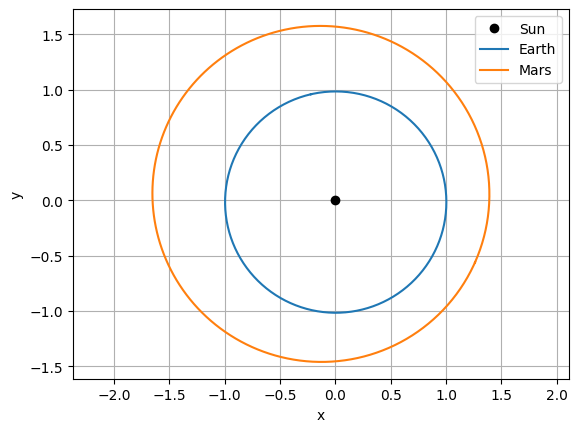

In [4]:
#> Evaluate trajectories
rre = evaluate_trajectory_1day(earth_orbit_params)
rrm = evaluate_trajectory_1day(mars_orbit_params)

#> Plot
plt.plot(0,0, 'o', color='black', label='Sun')
plt.plot(rre[0,:], rre[1,:], '-', label='Earth')
plt.plot(rrm[0,:], rrm[1,:], '-', label='Mars')
plt.xlabel('x');  plt.ylabel('y');  plt.legend(); plt.axis('equal');  plt.grid()


### Calcolo degli angoli

Angoli di Sole e Marte, visti dalla Terra. Queste erano le uniche misure note a Keplero, che non conosceva né la distanza tra Terra e Sole, né la distanza tra Marte e Sole, e nemmeno la forma delle traiettorie dei pianeti attorno al Sole

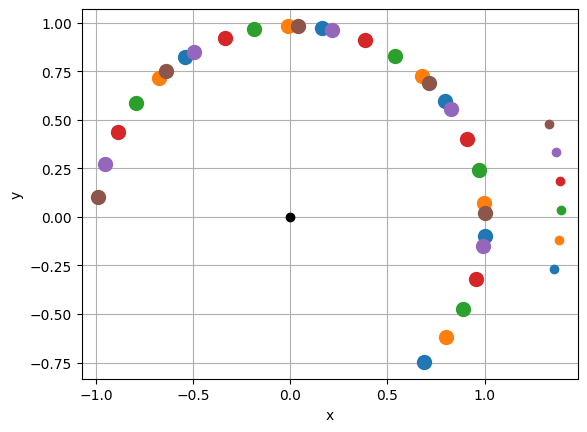

In [5]:
#> Given initial conditions, sample relative positions every Mars year
im0 = 20
im0n, im0d = 6, 10
im0v = im0 + np.arange(0, im0n) * im0d
nmars_years = 5
marsT = mars_orbit_params['T']
earthT = earth_orbit_params['T']

ie_points = {}
im_points = {}
th_m = {}   # angle of Mars as seen from the Earth
th_s = {}   # angle of Sun as seen from the Earth

#> Evaluate indices of days of Earth and Mars
imars_years = 0
for i0 in im0v:
    ie_points[imars_years] = ( i0 + marsT * np.arange(nmars_years) ) % earthT
    im_points[imars_years] =   i0 % marsT

    th_m[imars_years] = np.arctan2(
        rrm[1, im_points[imars_years]] - rre[1, ie_points[imars_years]],
        rrm[0, im_points[imars_years]] - rre[0, ie_points[imars_years]])
    th_s[imars_years] = np.arctan2(
        - rre[1,ie_points[imars_years]], - rre[0,ie_points[imars_years]])

    imars_years += 1

# check sampling
#> Plot of the registered positions
plt.plot(0,0, 'o', color='black', label='Sun')
for i in ie_points:
    plt.plot(rre[0, ie_points[i]], rre[1, ie_points[i]], 'o', color=plt.cm.tab10(i), markersize=10)
    plt.plot(rrm[0, im_points[i]], rrm[1, im_points[i]], 'o', color=plt.cm.tab10(i))
plt.xlabel('x');  plt.ylabel('y');  plt.axis('equal');  plt.grid()


### Recupero delle orbite dalle misure degli angoli